## Compare polynomials between the old version with the new version

In [1]:
# basic python packages
import numpy as np
import pandas as pd

# specific python packages
import minterpy as mp
import cvxpy as cp
# added by Damar for handling equations
import sympy as sp

# visualisation tools
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.widgets  import RectangleSelector
from minterpy.core.utils import get_exponent_matrix
import matplotlib.patches as patches

# others
import minterpy_functions as mf
import pickle
import json_tricks as json
# import json
from collections import OrderedDict

In [2]:
poly_info = json.load('240916_PCO_M-60_poly.json')
# poly_info = json.load('240916_PCO_M-60_poly_new.json')
print(poly_info)

OrderedDict([('coeffs', array([-1.56678878e+01, -1.01399182e+01, -6.81126525e+00, -1.79379843e+00,
       -1.02946851e+00,  7.96724431e-02, -1.22053344e-01, -2.84217094e-13,
        1.42108547e-14,  2.78023341e+00,  1.46935410e+00, -3.83250475e-01,
       -3.64153152e-14,  6.21724894e-15,  3.55271368e-15,  1.95399252e-14,
        9.94759830e-14, -1.29890892e+00, -4.06608947e-01,  1.80242121e-01,
       -1.14923304e-01, -5.59552404e-14, -3.28626015e-13,  1.59872116e-14,
       -7.10542736e-14, -3.99772386e+00, -1.92255952e+00, -3.82634436e-01,
       -1.22450240e-01, -2.48689958e-14,  9.05941988e-14, -1.24344979e-14,
       -2.13162821e-14,  1.16162889e+00,  4.96161070e-01, -5.99520433e-15,
       -5.81756865e-14, -2.22044605e-15, -5.95079541e-14,  1.33226763e-14,
        3.55271368e-15, -8.20478667e-01, -2.79665961e-01, -1.06581410e-14,
       -4.62361375e-02, -3.10862447e-15,  3.19744231e-14,  4.44089210e-15,
        2.48689958e-14, -8.81056490e-01, -1.94555298e-01,  3.42698772e-01,
 

In [3]:
exponents = poly_info['exponents']
coeffs = poly_info['coeffs']

mi = mp.MultiIndexSet(exponents, lp_degree=2.0)  # NOTE: lp_degree must now be specified

sparse_poly_model = mp.NewtonPolynomial(mi, coeffs)


In [4]:
exp = poly_info['exponents']
coeff = poly_info['coeffs']
lower_bounds = poly_info['lower_bounds']
upper_bounds = poly_info['upper_bounds']

nce = [10,70] # range of nce
num_points_in_grid = 61
xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
eval_points = np.array([[x, 12, 6, 14] for x in xvals])
print(eval_points)
eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)
print(eval_vals)


[[10. 12.  6. 14.]
 [11. 12.  6. 14.]
 [12. 12.  6. 14.]
 [13. 12.  6. 14.]
 [14. 12.  6. 14.]
 [15. 12.  6. 14.]
 [16. 12.  6. 14.]
 [17. 12.  6. 14.]
 [18. 12.  6. 14.]
 [19. 12.  6. 14.]
 [20. 12.  6. 14.]
 [21. 12.  6. 14.]
 [22. 12.  6. 14.]
 [23. 12.  6. 14.]
 [24. 12.  6. 14.]
 [25. 12.  6. 14.]
 [26. 12.  6. 14.]
 [27. 12.  6. 14.]
 [28. 12.  6. 14.]
 [29. 12.  6. 14.]
 [30. 12.  6. 14.]
 [31. 12.  6. 14.]
 [32. 12.  6. 14.]
 [33. 12.  6. 14.]
 [34. 12.  6. 14.]
 [35. 12.  6. 14.]
 [36. 12.  6. 14.]
 [37. 12.  6. 14.]
 [38. 12.  6. 14.]
 [39. 12.  6. 14.]
 [40. 12.  6. 14.]
 [41. 12.  6. 14.]
 [42. 12.  6. 14.]
 [43. 12.  6. 14.]
 [44. 12.  6. 14.]
 [45. 12.  6. 14.]
 [46. 12.  6. 14.]
 [47. 12.  6. 14.]
 [48. 12.  6. 14.]
 [49. 12.  6. 14.]
 [50. 12.  6. 14.]
 [51. 12.  6. 14.]
 [52. 12.  6. 14.]
 [53. 12.  6. 14.]
 [54. 12.  6. 14.]
 [55. 12.  6. 14.]
 [56. 12.  6. 14.]
 [57. 12.  6. 14.]
 [58. 12.  6. 14.]
 [59. 12.  6. 14.]
 [60. 12.  6. 14.]
 [61. 12.  6. 14.]
 [62. 12.  6

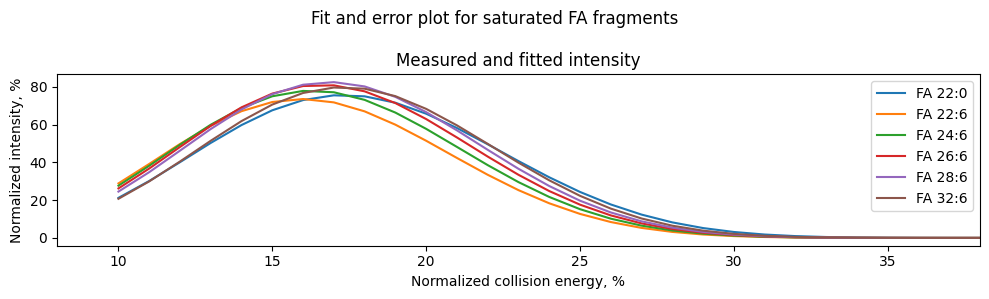

In [28]:
# color definition for plots
colors = [('tab:blue', '#1f77b4'), ('tab:orange', '#ff7f0e'), ('tab:green', '#2ca02c'), ('tab:red', '#d62728'), ('tab:purple', '#9467bd'), ('tab:brown', '#8c564b'), ('tab:pink', '#e377c2'), ('tab:gray', '#7f7f7f'), ('tab:olive', '#bcbd22'), ('tab:cyan', '#17becf')]

nce = [10,70] # range of nce
FA_oi = [[22, 0, 0], [22, 6, 4], [24, 6, 6], [26, 6, 8], [28, 6, 10], [32, 6, 14]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1, 1, figsize=(10, 3))

fig.suptitle("Fit and error plot for saturated FA fragments")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    ax.plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    ax.set_xlim(8,38)

# axes label     
ax.set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()